# **Market Sizing — TAM / SAM / SOM**

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.config import get_path, MARKET_PARAMS
from src.market_sizing import compute_tam_sam_som, market_sizing_table, sensitivity_market_size
from src.viz import apply_project_style, save_figure, plot_market_sizing_funnel

apply_project_style()
print("Setup complete.")

Setup complete.


## Main Assumptions (from configs/config.yaml)

All assumptions are documented and must be reviewed before client presentation.

In [2]:
print("MARKET SIZING ASSUMPTIONS")
print("="*50)
for key, val in MARKET_PARAMS.items():
    print(f"  {key:<35} : {val}")

MARKET SIZING ASSUMPTIONS
  nigeria_adults_2023_m               : 106.0
  banked_rate_2023                    : 0.45
  mobile_money_rate_2023              : 0.35
  smartphone_penetration              : 0.4
  financially_excluded_m              : 35.0
  avg_annual_txn_value_usd            : 850.0
  sam_capture_rate                    : 0.18
  som_capture_rate_y1                 : 0.02
  som_capture_rate_y3                 : 0.07
  fx_usd_ngn_2023                     : 1500.0


## TAM / SAM / SOM Calculation

In [3]:
# I computed the market sizing using the bottom-up methodology.
results = compute_tam_sam_som()

# Display a summary table
df_sizing = market_sizing_table(results)
display(df_sizing[['Market', 'Population (M)', '% of Adults',
                    'Avg Txn/User (USD/yr)', 'Market Size (USD M)']])

# Save to reports
tables_dir = get_path("reports_tables")
df_sizing.to_csv(tables_dir / "market_sizing_summary.csv", index=False)
print(f"\nSaved to reports/tables/")

,Market,Population (M),% of Adults,Avg Txn/User (USD/yr),Market Size (USD M)
0,TAM,106.00,100.0,850.0,"$90,100M"
1,SAM,42.40,40.0,850.0,"$36,040M"
2,SOM_Y1,0.85,0.8,850.0,$721M
3,SOM_Y3,2.97,2.8,850.0,"$2,523M"



Saved to reports/tables/


In [4]:
tam  = results['TAM']
sam  = results['SAM']
sy1  = results['SOM_Y1']
sy3  = results['SOM_Y3']

print("MARKET SIZING NARRATIVE")
print("="*60)
print(f"  TAM : {tam.population_m:.0f}M adults × ${tam.avg_txn_value_usd:.0f}/yr = ${tam.market_size_usd_m:,.0f}M/yr")
print(f"  SAM : {sam.population_m:.0f}M smartphone users = ${sam.market_size_usd_m:,.0f}M/yr")
print(f"  SOM (Y1) : ${sy1.market_size_usd_m:,.0f}M/yr  ({sy1.population_m:.2f}M users targeted)")
print(f"  SOM (Y3) : ${sy3.market_size_usd_m:,.0f}M/yr  ({sy3.population_m:.2f}M users targeted)")

MARKET SIZING NARRATIVE
  TAM : 106M adults × $850/yr = $90,100M/yr
  SAM : 42M smartphone users = $36,040M/yr
  SOM (Y1) : $721M/yr  (0.85M users targeted)
  SOM (Y3) : $2,523M/yr  (2.97M users targeted)


## Market Sizing Funnel Chart

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig06_market_sizing_funnel.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig06_market_sizing_funnel.pdf


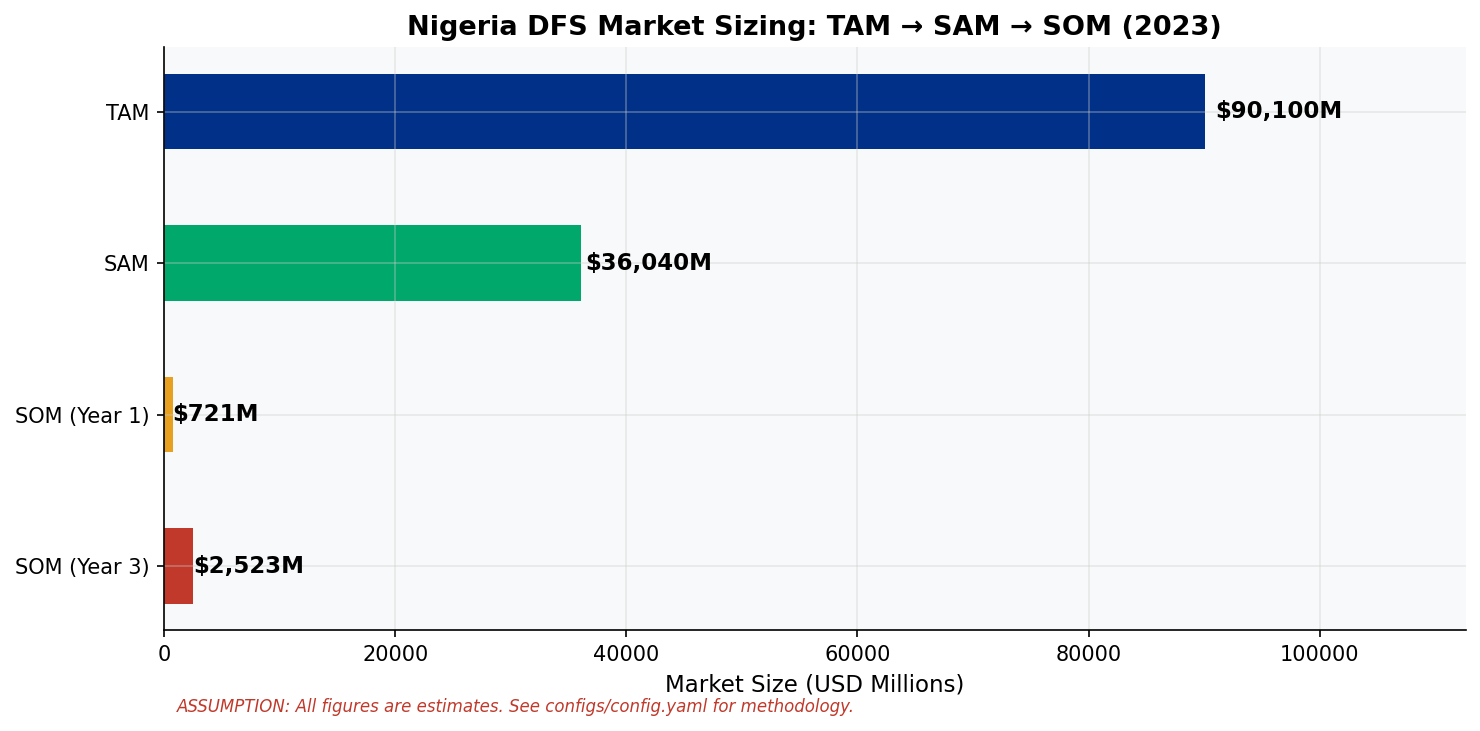

In [5]:
fig = plot_market_sizing_funnel(
    tam_m=results['TAM'].market_size_usd_m,
    sam_m=results['SAM'].market_size_usd_m,
    som_y1_m=results['SOM_Y1'].market_size_usd_m,
    som_y3_m=results['SOM_Y3'].market_size_usd_m,
)
save_figure(fig, "fig06_market_sizing_funnel.png")
plt.show()

## Sensitivity Analysis

How sensitive is the SOM to ARPU assumptions? I tested a range of ARPU values (pessimistic → optimistic).

In [6]:
arpu_range  = [6, 8, 10, 12, 14, 16, 20]
users_range = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]   # millions

df_sens = sensitivity_market_size(arpu_range, users_range)

print("SENSITIVITY: Annual Revenue (USD M) by ARPU × User Base")
print("ASSUMPTION: This is a simplified revenue estimate, not a full model.")
print()
display(df_sens)
df_sens.to_csv(tables_dir / "market_sizing_sensitivity.csv")
print(f"\nSaved to reports/tables/")

SENSITIVITY: Annual Revenue (USD M) by ARPU × User Base
ASSUMPTION: This is a simplified revenue estimate, not a full model.



,0.5M users,1.0M users,1.5M users,2.0M users,3.0M users,5.0M users
$6/user ARPU,$3M,$6M,$9M,$12M,$18M,$30M
$8/user ARPU,$4M,$8M,$12M,$16M,$24M,$40M
$10/user ARPU,$5M,$10M,$15M,$20M,$30M,$50M
$12/user ARPU,$6M,$12M,$18M,$24M,$36M,$60M
$14/user ARPU,$7M,$14M,$21M,$28M,$42M,$70M
$16/user ARPU,$8M,$16M,$24M,$32M,$48M,$80M
$20/user ARPU,$10M,$20M,$30M,$40M,$60M,$100M



Saved to reports/tables/


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig07_market_sensitivity_heatmap.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig07_market_sensitivity_heatmap.pdf


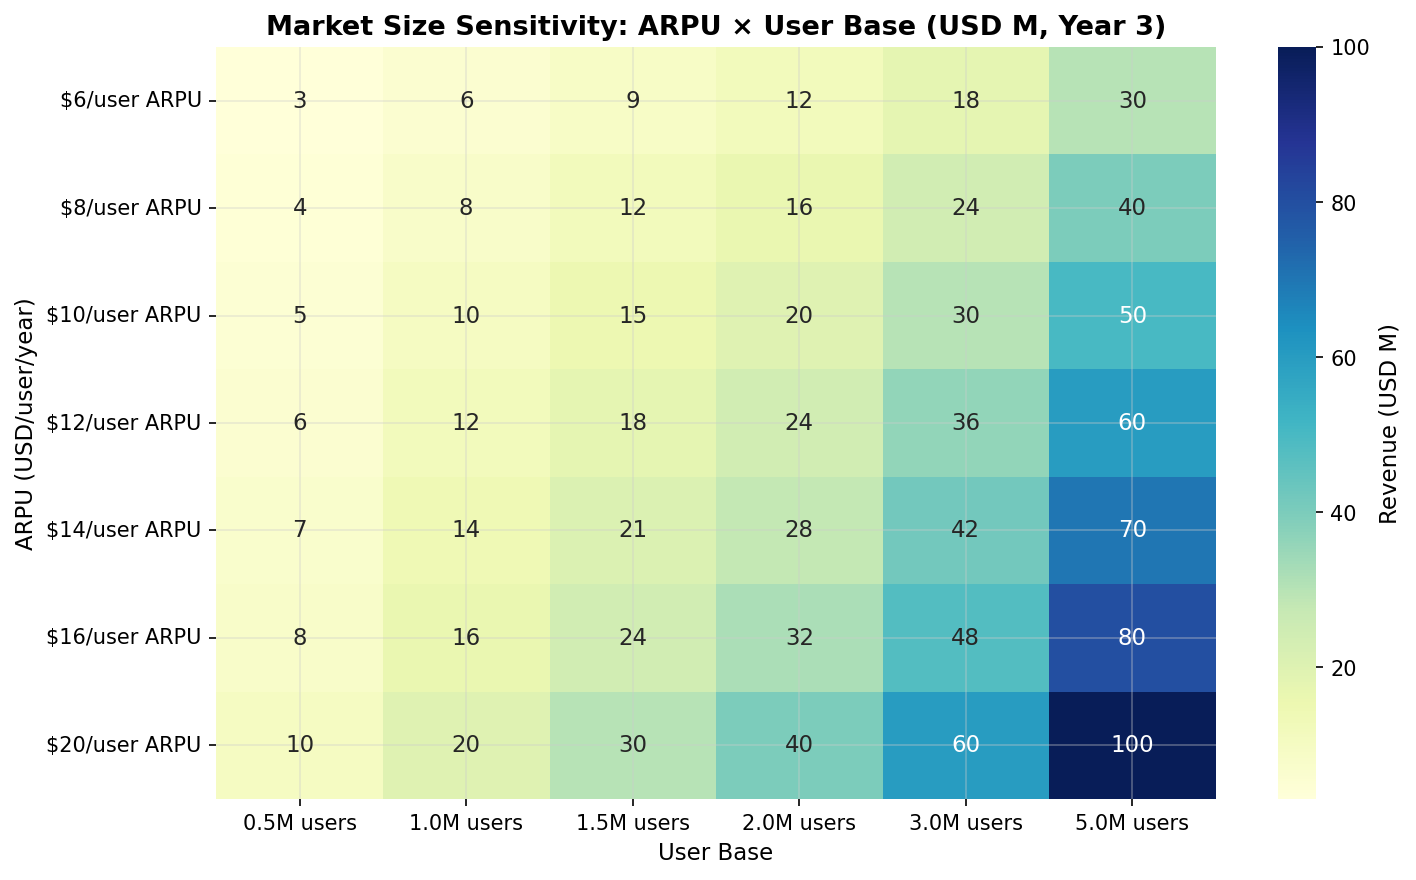

In [7]:
import numpy as np
import seaborn as sns

# Convert string cells to numeric for heatmap
numeric_data = df_sens.copy()
numeric_data = numeric_data.applymap(
    lambda x: float(x.replace('$','').replace('M','')) if isinstance(x, str) else x
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(numeric_data, annot=True, fmt='.0f', cmap='YlGnBu',
            ax=ax, cbar_kws={'label': 'Revenue (USD M)'})
ax.set_title("Market Size Sensitivity: ARPU × User Base (USD M, Year 3)")
ax.set_xlabel("User Base")
ax.set_ylabel("ARPU (USD/user/year)")
plt.tight_layout()
save_figure(fig, "fig07_market_sensitivity_heatmap.png")
plt.show()